# ArGuard Task 1 — Exploring the data

This notebook walks through the official splits of the ArGuard Task 1 dataset:

* Subtask 1A — binary `Hateful` / `Not Hateful` classification.
* Subtask 1B — multi-label fine-grained sub-types for **hateful** memes.

We will load the downloaded JSONL files, browse a few example records, and plot the label distributions.

**Prerequisite:** run `python data/download_data.py` from the `task1/` directory before executing this notebook.

In [6]:
!conda init
!source /export/home/alishahrour/anaconda3/bin/activate
!conda init
!conda activate ArGuard

no change     /export/home/alishahrour/anaconda3/condabin/conda
no change     /export/home/alishahrour/anaconda3/bin/conda
no change     /export/home/alishahrour/anaconda3/bin/conda-env
no change     /export/home/alishahrour/anaconda3/bin/activate
no change     /export/home/alishahrour/anaconda3/bin/deactivate
no change     /export/home/alishahrour/anaconda3/etc/profile.d/conda.sh
no change     /export/home/alishahrour/anaconda3/etc/fish/conf.d/conda.fish
no change     /export/home/alishahrour/anaconda3/shell/condabin/Conda.psm1
no change     /export/home/alishahrour/anaconda3/shell/condabin/conda-hook.ps1
no change     /export/home/alishahrour/anaconda3/lib/python3.12/site-packages/xontrib/conda.xsh
no change     /export/home/alishahrour/anaconda3/etc/profile.d/conda.csh
no change     /export/home/alishahrour/.bashrc
No action taken.
no change     /export/home/alishahrour/anaconda3/condabin/conda
no change     /export/home/alishahrour/anaconda3/bin/conda
no change     /export/home/ali

In [7]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

# Make the baselines/ package importable from this notebook.
TASK1 = Path.cwd().resolve()
while TASK1.name != 'task1' and TASK1.parent != TASK1:
    TASK1 = TASK1.parent
sys.path.insert(0, str(TASK1 / 'baselines'))

from io_utils import read_jsonl
from labels import BINARY_LABELS, HATEFUL_SUBTYPES, NONHATEFUL_SUBTYPES

DATA = TASK1 / 'data'
SPLITS = DATA / 'splits'
IMG = DATA / 'img'
print('data dir:', DATA)

data dir: /export/home/alishahrour/Shared_Task/ArGuard-2026-tasks/task1/data


## 1. Load splits

In [8]:
splits = {}
for name in ('train', 'dev', 'dev_test', 'test'):
    p = SPLITS / f'{name}.jsonl'
    if p.exists():
        splits[name] = read_jsonl(p)
        print(f'{name:9s}  {len(splits[name]):6,d} records')
    else:
        print(f'{name:9s}  (not on disk)')

train       3,500 records
dev           500 records
dev_test      500 records
test       (not on disk)


In [9]:
# Inspect the schema of one record from train
ex = splits['train'][0]
print(json.dumps({k: (v if k != 'annotations' else f'<{len(v)} entries>') for k, v in ex.items()}, ensure_ascii=False, indent=2))

{
  "id": "102396787_870863910087838_1388595117576683520_n.jpg",
  "image_path": "img/102396787_870863910087838_1388595117576683520_n.jpg",
  "text": "المتظاهرون في أمريكا\nالله يرحمك يا جورج يا أخويا",
  "label": "Hateful",
  "fine_grained_label": [
    "Dehumanization",
    "Mocking"
  ],
  "annotations": "<0 entries>"
}


## 2. Binary label distribution (Subtask 1A)

In [10]:
for name, recs in splits.items():
    c = Counter(r.get('label') for r in recs)
    total = sum(c.values()) or 1
    parts = ', '.join(f'{k or "(unlabeled)"}={v} ({100*v/total:.1f}%)' for k, v in c.most_common())
    print(f'{name:9s}  {parts}')

train      Not Hateful=2176 (62.2%), Hateful=1324 (37.8%)
dev        Not Hateful=311 (62.2%), Hateful=189 (37.8%)
dev_test   (unlabeled)=500 (100.0%)


## 3. Fine-grained sub-types (Subtask 1B)

In [11]:
def fg_counts(records, allowed):
    c = Counter()
    for r in records:
        for l in (r.get('fine_grained_label') or []):
            if l in allowed:
                c[l] += 1
    return c

hateful = {n: fg_counts([r for r in recs if r.get('label') == 'Hateful'], HATEFUL_SUBTYPES) for n, recs in splits.items() if recs}
nonhate = {n: fg_counts([r for r in recs if r.get('label') == 'Not Hateful'], NONHATEFUL_SUBTYPES) for n, recs in splits.items() if recs}

print('Hateful sub-types  (train):', dict(hateful.get('train', {})))
print('Non-hateful sub-types (train):', dict(nonhate.get('train', {})))

Hateful sub-types  (train): {'Dehumanization': 247, 'Mocking': 706, 'Incitement': 320, 'Slurs': 252, 'Other': 18, 'Inferiority': 57, 'Contempt': 107, 'Exclusion': 10}
Non-hateful sub-types (train): {'Humor': 863, 'Other': 380, 'Sarcasm': 934}


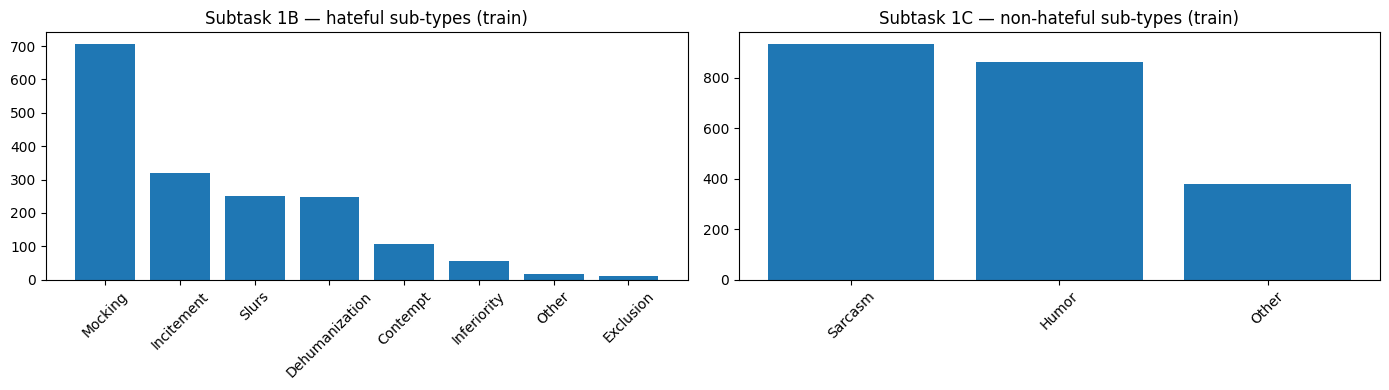

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if 'train' in hateful:
    items = sorted(hateful['train'].items(), key=lambda kv: kv[1], reverse=True)
    axes[0].bar([k for k, _ in items], [v for _, v in items])
    axes[0].set_title('Subtask 1B \u2014 hateful sub-types (train)')
    axes[0].tick_params(axis='x', rotation=45)
if 'train' in nonhate:
    items = sorted(nonhate['train'].items(), key=lambda kv: kv[1], reverse=True)
    axes[1].bar([k for k, _ in items], [v for _, v in items])
    axes[1].set_title('Subtask 1B \u2014 non-hateful sub-types (train)')
    axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Peek at a meme

id    : 102396787_870863910087838_1388595117576683520_n.jpg
text  : المتظاهرون في أمريكا
الله يرحمك يا جورج يا أخويا
label : Hateful
fg    : ['Dehumanization', 'Mocking']


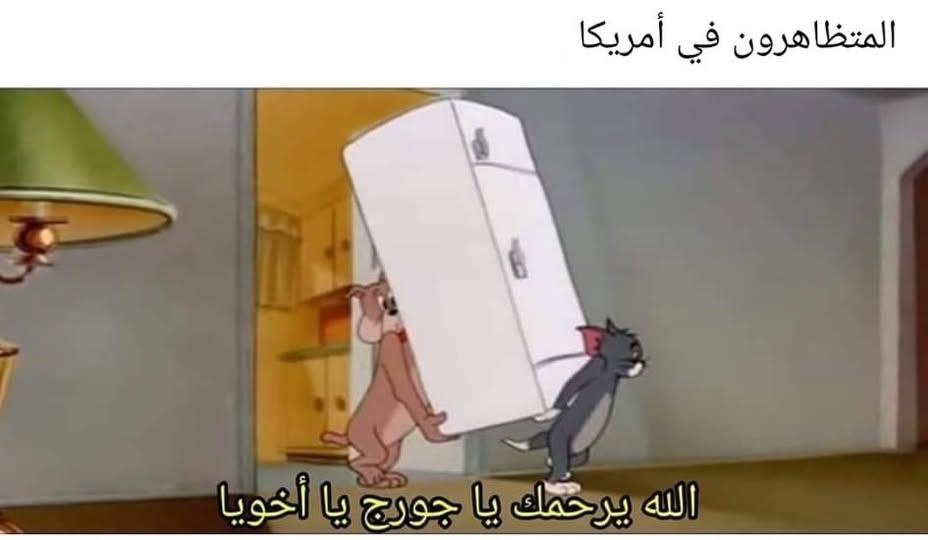

In [13]:
rec = splits['train'][0]
img_path = DATA / rec['image_path']
img = Image.open(img_path).convert('RGB')
print('id    :', rec['id'])
print('text  :', rec['text'][:200])
print('label :', rec['label'])
print('fg    :', rec['fine_grained_label'])
img

## 5. Next steps

* `02_text_baseline.ipynb` \u2014 train a text-only BERT classifier.
* `03_image_baseline.ipynb` \u2014 train an image-only ViT classifier.
* `04_multimodal_baseline.ipynb` \u2014 late-fusion multimodal classifier.
* `05_simple_baselines.ipynb` \u2014 majority / random baselines + format checker + scorer.